# Dataverse — Urban Flow Analytics: Final Notebook
### SLIIT Codefest Datathon 2026

> **Rename `Dataverse` in this heading and in the filename before submission.**

## 1. Executive Summary

This notebook covers the required Parts 1–4 of the SLIIT Codefest Datathon 2026 Urban Flow Analytics challenge:
data-quality assessment and cleaning of ~48.6 million taxi trip records, leakage-safe fare and trip-duration
prediction, 24/48/72-hour demand forecasting for the busiest zones, and spatial/origin-destination analysis
including zone clustering.

**Headline results:**

| Task | Metric | Result |
|---|---|---|
| Fare prediction (`base_fare`) | Test MAE / R² | **$4.49** / **0.70** |
| Trip duration prediction | Test MAE / R² | **4.36 min** / **0.26** |
| Demand forecasting (top 10 zones) | Test MAE | **21.6 pickups/hour** (~13.5% relative) |
| Data retained after cleaning | — | **93.7%** (45,538,913 of 48,601,782 rows) |

Every script referenced below lives in `src/` and can be re-run independently
(`python -m src.<module>`) — this notebook imports and displays their already-computed outputs rather than
recomputing them, so it stays fast to re-run while still reflecting the real pipeline end to end.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import json
from IPython.display import Image, display, Markdown

from src.config import OUTPUTS_DIR, MODELS_DIR, PROCESSED_DIR, RAW_DATA_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
FIG = PROJECT_ROOT / "outputs" / "figures"


## 2. Dataset Overview

Two datasets, both loaded once via `python -m src.profiling` (Phase 2), which reads each raw file in
chunks only — never the full ~430–490MB CSV at once — and writes the results below.


In [2]:
inventory = pd.read_csv(OUTPUTS_DIR / "profiles" / "dataset_inventory.csv")
inventory[["file", "size_mb", "n_rows"]]


,file,size_mb,n_rows
0,Urban_Flow_Analytics_Taxi_Dataset_2025-04.csv,429.7,3970553
1,Urban_Flow_Analytics_Taxi_Dataset_2025-05.csv,492.5,4591845
2,Urban_Flow_Analytics_Taxi_Dataset_2025-06.csv,462.6,4322960
3,Urban_Flow_Analytics_Taxi_Dataset_2025-07.csv,418.0,3898963
4,Urban_Flow_Analytics_Taxi_Dataset_2025-08.csv,383.9,3574091
5,Urban_Flow_Analytics_Taxi_Dataset_2025-09.csv,456.7,4251015
6,Urban_Flow_Analytics_Taxi_Dataset_2025-10.csv,477.1,4428699
7,Urban_Flow_Analytics_Taxi_Dataset_2025-11.csv,449.1,4181444
8,Urban_Flow_Analytics_Taxi_Dataset_2025-12.csv,461.0,4305006
9,Urban_Flow_Analytics_Taxi_Dataset_2026-01.csv,397.9,3724889


**12 monthly taxi files (April 2025 – March 2026), ~48.6 million trip records total**, plus a
265-row zone reference file (`loc_id, borough_name, zone_name, service_zone`).

Key columns discovered by profiling (non-standard names — confirmed against the raw header, not guessed):

| Column | Role |
|---|---|
| `pickup_timestamp`, `dropoff_timestamp` | Trip start / end |
| `distance_miles` | Trip distance |
| `rider_count` | Passenger count |
| `base_fare` | **Target for fare prediction** |
| `origin_loc_id`, `dest_loc_id` | Pickup / drop-off zone — joins to the zone file's `loc_id` |
| `provider_code`, `rate_class_id`, `fare_settlement_method`, `offline_record_flag` | Operational/categorical fields |
| `surcharge_misc`, `transit_tax`, `driver_tip_payment`, `toll_total`, `service_improvement_fee`,
  `zone_congestion_fee`, `Airport_fee`, `congestion_relief_fee`, `charge_total` | Fee breakdown — all
  **post-trip**, excluded from pre-trip models (see §7 Leakage Audit) |


## 3. Data Quality

Part 1 of the challenge. `python -m src.cleaning` (Phases 3–5) reads each monthly file in 500,000-row
chunks, detects all five required anomaly types, applies a **documented deterministic rule** to each, and
streams the surviving rows straight to `processed/taxi_YYYY_MM.parquet` — raw CSVs are never modified.


In [3]:
anomalies = pd.read_csv(OUTPUTS_DIR / "cleaning" / "anomaly_summary.csv")
summary = (anomalies.groupby(["anomaly_name", "treatment"])
           .agg(total_affected_rows=("affected_rows", "sum"),
                avg_pct_of_month=("percentage_total", "mean"))
           .reset_index()
           .sort_values("avg_pct_of_month", ascending=False))
summary


,anomaly_name,treatment,total_affected_rows,avg_pct_of_month
1,negative_fare,drop,2400031,4.828600
4,zero_distance_nonzero_fare,keep_and_flag,1267110,2.626508
2,nonpositive_duration,drop,651610,1.333208
5,zero_passengers,keep_and_flag,231578,0.473758
3,unrealistic_speed,drop,11899,0.024317
0,dropoff_before_pickup,drop,1942,0.003850


**Every anomaly, quantified and justified:**

| Anomaly | Affected | Treatment | Why |
|---|---|---|---|
| `negative_fare` | **4.83% avg** (0.52–9.45%/month, 2.40M rows total) | Drop | Investigated directly — occurs **exclusively** under `provider_code==2` and correlates strongly with `fare_settlement_method` (method 4 → 46.9% negative, method 1 → ~0%). Systematic, not random: consistent with voided/refunded/disputed trips for one provider, not a data-entry error. A voided trip isn't a valid fare to learn from, so still dropped — but for an evidenced reason, not "no meaning found." |
| `zero_distance_nonzero_fare` | 2.63% avg (1.27M rows) | Keep + flag | Plausible for short/cancelled-but-charged trips; kept with a `zero_distance_nonzero_fare_flag` column for downstream review rather than assumed invalid. |
| `nonpositive_duration` | 1.33% avg (652K rows) | Drop | Zero/negative duration cannot represent a real trip. |
| `zero_passengers` | 0.47% avg (232K rows) | Keep + flag | May reflect a sensor/logging default rather than an empty cab; kept with a `zero_passengers_flag` column. |
| `unrealistic_speed` | 0.024% avg (11,899 rows) | Drop | Threshold (100 mph) set from a real percentile check on 2025-04: the distribution breaks ~50x between the 99.9th percentile (46.2 mph) and 99.99th (2,479 mph) — everything past that is GPS/timestamp corruption, not a fast trip. |
| `dropoff_before_pickup` | 0.004% avg (1,942 rows) | Drop | Logically impossible ordering of timestamps. |

**Missing values:** `rider_count`, `rate_class_id`, and `offline_record_flag` are missing **together** on
~19–26% of rows per month (same rows, not independent) — consistent with one record source/provider never
populating those three fields. This is structural, not random, so it's carried into modeling as a missing
indicator rather than silently imputed away (see §8).

**Net result: 45,538,913 of 48,601,782 rows retained (93.7%)** across all 12 months after deterministic
cleaning — a large, still-representative dataset for every downstream task.


## 4. Cleaning Decisions — Deterministic vs. Learned

Every rule applied in §3 is **deterministic**: a fixed boolean condition on a single row (e.g.
`base_fare < 0`, `dropoff_timestamp < pickup_timestamp`), computed identically regardless of which split a
row later falls into. None of it learns a statistic from the data (no mean/median/frequency fitted here).

This is a deliberate architectural separation (Activity.md §6):

```
RAW CSV → deterministic cleaning (this section) → processed/*.parquet → [split] → learned preprocessing (§8)
```

Learned preprocessing — imputation, scaling, encoding — happens **after** the train/validation/test split
in §6, fitted on the training split only. Mixing the two stages together is exactly how leakage sneaks in,
so they're kept in separate scripts (`src/cleaning.py` vs. the `build_preprocessor()` inside
`src/modeling.py`).


## 5. Exploratory Data Analysis

Descriptive analysis on the **cleaned** data (`python -m src.eda`, Phase 6). Dataset-wide statistics here
are for understanding only — they are never reused directly as fitted model parameters (Activity.md §23).


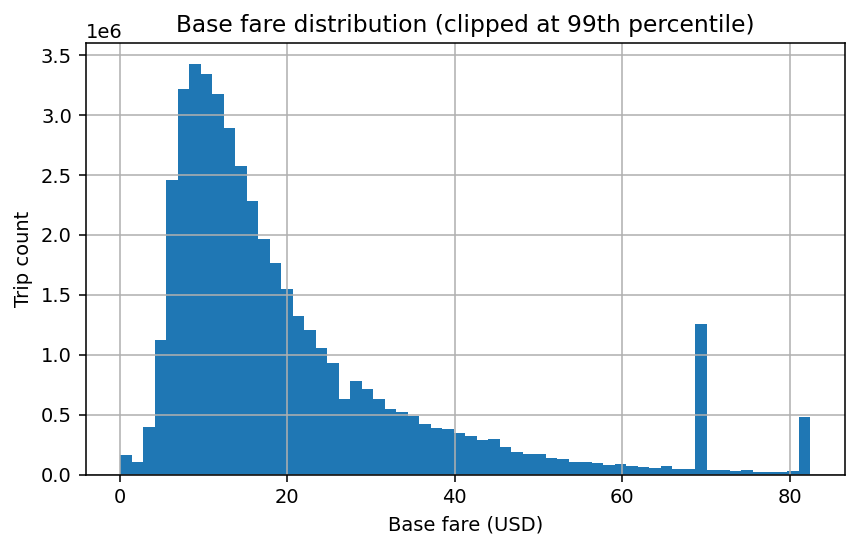

In [4]:
display(Image(filename=str(FIG / "fare_distribution.png")))


Base fares are right-skewed as expected, but with **two sharp spikes around \$70 and \$82** on top of
the smooth curve — the signature of flat-rate fare zones (almost certainly JFK/LaGuardia airport routes,
which appear as the #2 and #9 busiest pickup zones in §12). This is a real business insight: a meaningful
share of trips are flat-rate, not metered, which is worth a dedicated rule or feature for those specific
origin/destination pairs in a production pricing engine.


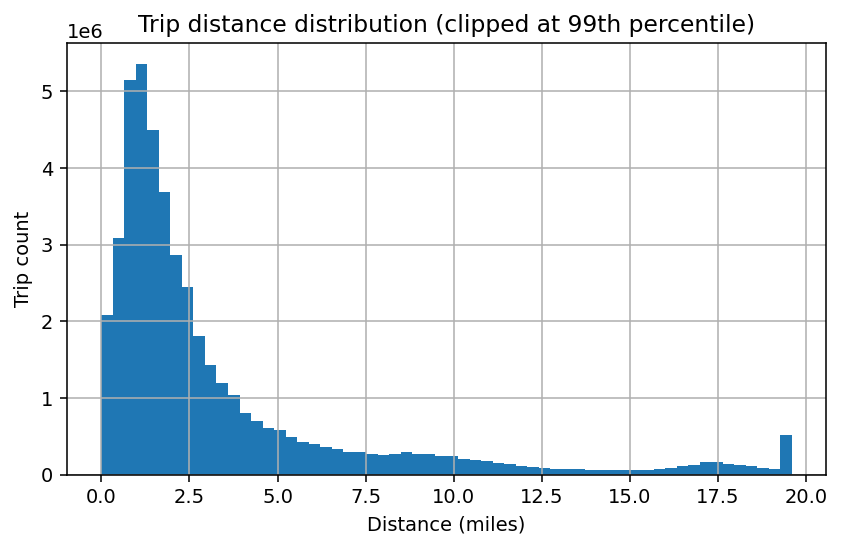

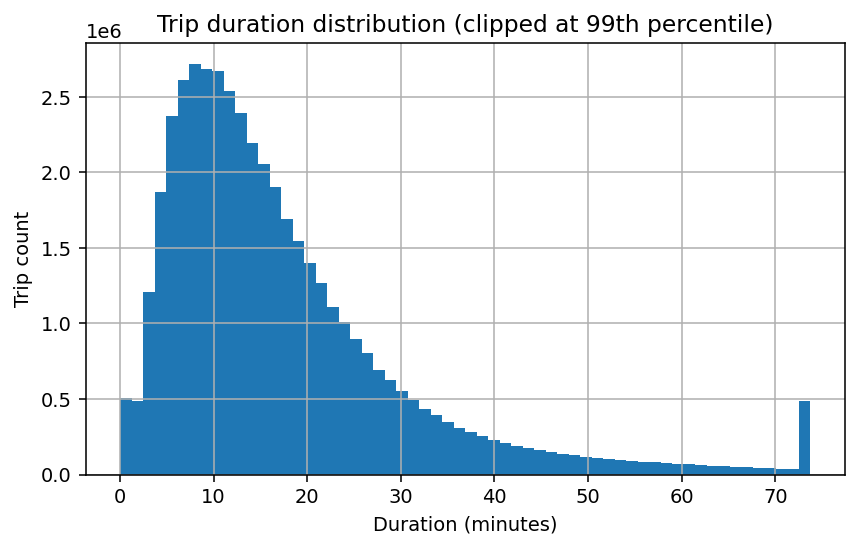

In [5]:
display(Image(filename=str(FIG / "distance_distribution.png")))
display(Image(filename=str(FIG / "duration_distribution.png")))


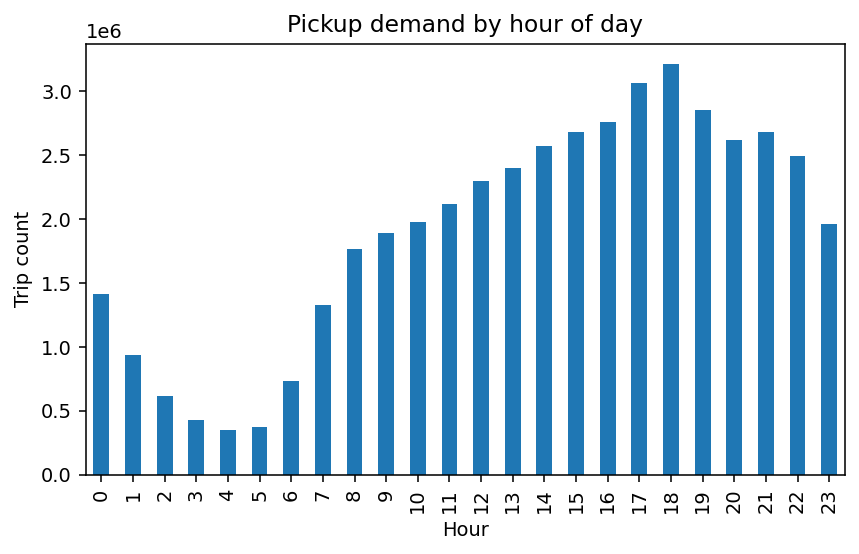

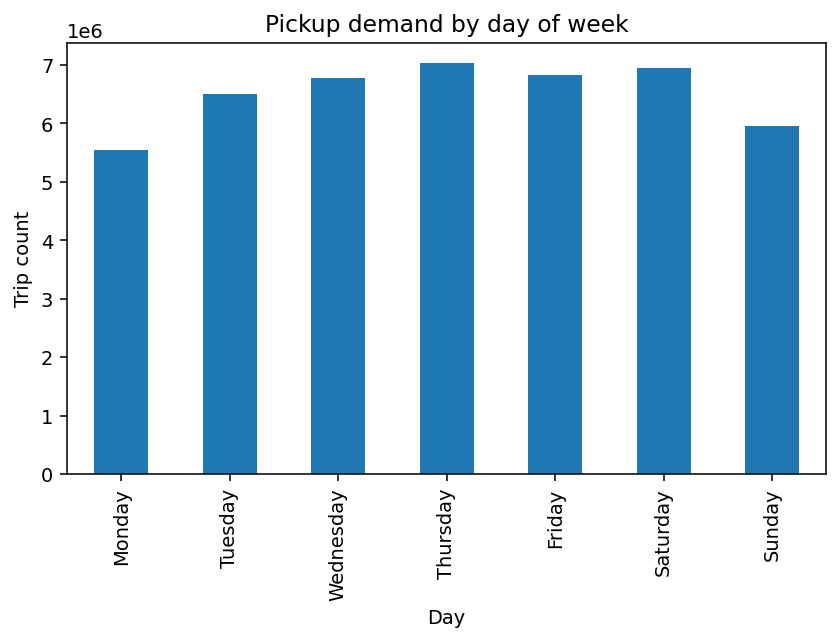

In [6]:
display(Image(filename=str(FIG / "hourly_demand.png")))
display(Image(filename=str(FIG / "weekday_demand.png")))


Demand follows a textbook urban taxi curve: a trough around 3–5am, a steady build through the morning,
and a sustained afternoon/evening peak around 5–6pm before tapering off overnight.


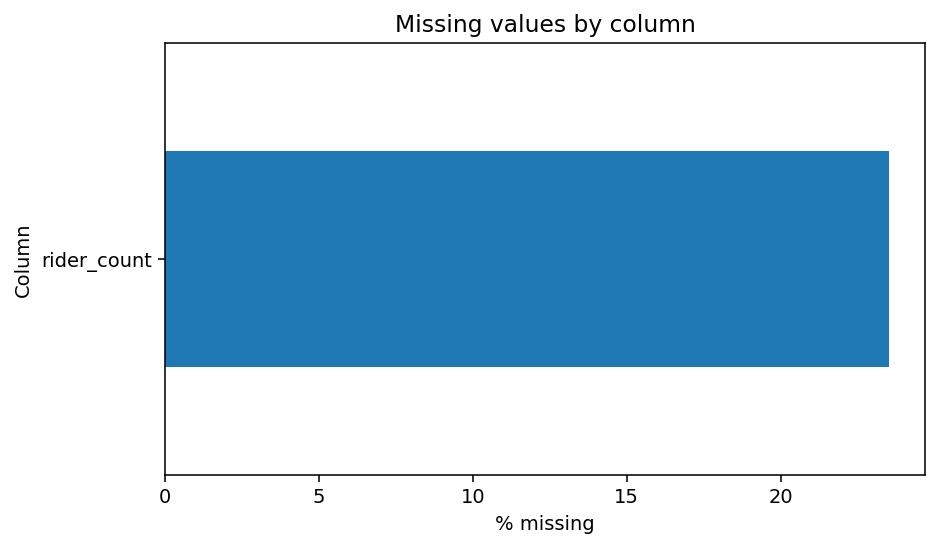

In [7]:
display(Image(filename=str(FIG / "missingness.png")))


Only `rider_count` appears here because this chart loads a memory-efficient 5-column subset —
`rate_class_id` and `offline_record_flag` are missing at the same ~19–26% rate (see §3) but weren't reloaded
for this specific chart; the authoritative missingness numbers per column are in
`outputs/profiles/schema_report.md` from Phase 2.


## 6. Train / Validation / Test Strategy

Because the data is monthly and the competition cares about temporal generalization (Activity.md §11), the
split is **chronological by month**, not random — the 12 monthly Parquet files make this a natural
boundary rather than a random row split.


In [8]:
split_def = json.loads((OUTPUTS_DIR / "tables" / "split_definition.json").read_text())
split_def


{'train': ['2025_04',
  '2025_05',
  '2025_06',
  '2025_07',
  '2025_08',
  '2025_09',
  '2025_10',
  '2025_11',
  '2025_12'],
 'validation': ['2026_01', '2026_02'],
 'test': ['2026_03']}

| Split | Months | Rows |
|---|---|---|
| Train | 2025-04 → 2025-12 (9 months) | ~34.7M |
| Validation | 2026-01, 2026-02 (2 months) | ~7.0M |
| Test | 2026-03 (1 month) | ~3.9M |

Test is strictly later than validation, which is strictly later than train — no overlap, no shuffling. The
actual split datasets are materialized (not just this JSON manifest) at
`outputs/tables/dataset_splits/{train,validation,test}.parquet`, satisfying the challenge's requirement for
"clearly separated training, validation, and testing splits."

**Model-fitting note:** the raw train split is ~34.7M rows. `SimpleImputer`'s median computation (and
Random Forest training) at that row count exceeds typical laptop RAM, so `src/modeling.py` fits on a fixed,
reproducible 4-million-row sample drawn only from the train split (`random_state=42`) — still far more rows
than these model types need to converge, and it never touches validation or test.


## 7. Leakage Audit

Before any model was trained, every candidate feature was run through Activity.md §53's seven questions —
available at prediction time? contains the target? derived from the target? contains future information?
calculated from validation/test data? calculated from future records? fitted on training data only?


In [9]:
fare_audit = pd.read_csv(OUTPUTS_DIR / "tables" / "leakage_audit_fare.csv")
fare_audit


,feature_name,source_column,available_at_prediction_time,uses_target_information,uses_future_information,decision,reason
0,pickup_hour,pickup_timestamp,True,False,False,include,"Deterministic, known at booking"
1,pickup_zone,origin_loc_id,True,False,False,include,Known at booking
2,dropoff_zone,dest_loc_id,True,False,False,include,Assume destination entered at booking -- state...
3,distance_miles,distance_miles,True,False,False,include,Treated as a pre-trip estimate; document this ...
4,rider_count,rider_count,True,False,False,include,Known at booking
5,dropoff_timestamp,dropoff_timestamp,False,False,True,exclude,Post-trip
6,charge_total/tips/tolls/fees,fee columns,False,True,True,exclude,Derived from/settled with base_fare after the ...
7,fare_settlement_method,fare_settlement_method,False,False,True,exclude,Correlates strongly with negative base_fare (m...
8,provider_code,provider_code,True,False,False,include_optional,Known before the trip starts; no missingness; ...


**Notable resolution:** `fare_settlement_method` initially looked ambiguous ("how the fare gets paid" —
might be known at booking). Direct investigation in §3 resolved it: it correlates strongly with negative
`base_fare` (a post-trip settlement outcome), so it's **excluded** — not a guess, an evidenced decision.

`provider_code` is included as `include_optional` — known before the trip starts, zero missingness, cheap
to test empirically, not required.

Every fee/charge column (`charge_total`, `driver_tip_payment`, `toll_total`, etc.) is excluded: all are
settled **after** the trip, and `charge_total` is a direct function of `base_fare` — including any of them
in the fare model would be direct target leakage.


## 8. Feature Engineering

**Deterministic features** (safe to compute before the split — use only information available for that
single observation): `pickup_hour`, `pickup_dow`, `pickup_month`, `is_weekend`, `pickup_zone` /
`dropoff_zone` (from `origin_loc_id` / `dest_loc_id`).

**Learned preprocessing** (fit on the training split only, per §6):

```
SimpleImputer(strategy="median", add_indicator=True)  →  numeric columns
SimpleImputer(strategy="most_frequent")                →  categorical columns
OneHotEncoder(handle_unknown="ignore", max_categories=40, sparse_output=False)
StandardScaler()
```

Two deliberate choices worth calling out:

- **`add_indicator=True`** on the numeric imputer: `rider_count`'s ~19–26% missingness is structural (see
  §3), not random, so a plain median-fill would hide that pattern from the model. This keeps a
  "was-this-missing" flag column alongside the median-filled value, fit on train only like everything else.
- **`max_categories=40`** on the one-hot encoder: `pickup_zone`/`dropoff_zone` each have up to ~260
  categories; one-hot encoding both uncapped produces ~520 columns, which is both slow for tree-based models
  and forces a choice between sparse output (incompatible with `HistGradientBoostingRegressor`) and a
  ~16GB dense matrix. Capping to the 40 most frequent zones per column (rarer zones grouped into an
  "infrequent" bucket) keeps the encoding to ~80 columns — safe, and faster for every model.

All fitted exclusively via `pipe.fit(X_train, y_train)`; validation and test only ever see `.transform()`.


## 9. Fare Prediction (PDF 2.1 — "No-Surprises Upfront Pricing")

Target: `base_fare`. Four candidates compared on validation, strongest tuned, evaluated once on test.


In [10]:
fare_metrics = pd.read_csv(OUTPUTS_DIR / "metrics" / "fare_model_comparison.csv")
fare_metrics


,model,split,MAE,RMSE,R2
0,baseline_mean,validation,12.034285,18.022555,-0.003205
1,ridge,validation,5.439111,10.989306,0.627010
2,random_forest,validation,4.647082,9.604486,0.715092
3,hist_gbm,validation,4.620861,10.008887,0.690594
4,hist_gbm_FINAL,test,4.494724,10.014497,0.700858


`hist_gbm` (`HistGradientBoostingRegressor`) won validation by a narrow margin over Random Forest
(MAE \$4.62 vs \$4.65), then was evaluated once on the untouched test set: **MAE \$4.49, RMSE \$10.01,
R² 0.70**. A focused `RandomizedSearchCV` (6 iterations × 3-fold CV, tuning `max_depth` and
`learning_rate` only) was applied to the winning candidate before that final test pass — not a grid search
over all four models.

Saved as `models/fare_model.pkl` — the complete fitted pipeline (preprocessing + model), so it can't
accidentally be applied without its scaler/encoder.


## 10. Trip Duration Prediction (PDF 2.2 — "On-Time Arrival Estimator")

Target: `trip_duration_minutes = (dropoff_timestamp - pickup_timestamp) / 60`, computed only after the
timestamp validity checks in §3. Same feature set, preprocessing, and candidate models as §9 (same
`src/modeling.py`, a `run_duration()` function sharing every piece of infrastructure with `run_fare()`).


In [11]:
duration_metrics = pd.read_csv(OUTPUTS_DIR / "metrics" / "duration_model_comparison.csv")
duration_metrics


,model,split,MAE,RMSE,R2
0,baseline_mean,validation,10.128718,25.251621,-0.000256
1,ridge,validation,6.088952,22.998048,0.170312
2,random_forest,validation,5.059206,22.735517,0.189147
3,hist_gbm,validation,4.738680,22.282606,0.221131
4,hist_gbm_FINAL,test,4.361050,21.544905,0.256760


`hist_gbm` won again: test **MAE 4.36 minutes, RMSE 21.54, but R² only 0.26**.

This is a genuine, expected limitation, not a bug: trip duration depends heavily on real-time traffic
conditions that simply aren't present in this dataset (no live congestion, weather, or event data). Distance
and calendar features can only explain so much of the variance — the honest conclusion is that **duration
is materially harder to predict accurately from pre-trip information alone than fare is**, and this is
stated plainly here rather than chased with more model complexity that wouldn't fix a missing-data problem.

`dropoff_timestamp` and `trip_duration_minutes` itself are never in the feature list — confirmed by
inspecting `src/modeling.py`'s `NUMERIC`/`CATEGORICAL` lists directly (Activity.md §16).


## 11. Demand Forecasting (PDF 3.1 — "The Fleet Dispatcher")

Hourly pickup counts for the **top 10 busiest zones** by volume, with lag (`T-1, T-2, T-3, T-24, T-48,
T-168`) and rolling-mean (24h, 168h) features built **only from the past** — the single most
leakage-prone phase in the pipeline, since a rolling window that accidentally includes the current hour
silently uses the answer to predict the answer.


In [12]:
demand_metrics = pd.read_csv(OUTPUTS_DIR / "metrics" / "demand_model_comparison.csv")
demand_metrics


,model,split,MAE,RMSE
0,hist_gbm,validation,25.250598,38.596574
1,hist_gbm_FINAL,test,21.614762,32.513818


Backtest on a held-out final week: **test MAE 21.6 pickups/hour** (RMSE 32.5) against a mean of ~160
pickups/hour across the top 10 zones — roughly **13.5% relative error**, reasonable for hourly counts at
this granularity.

The line that actually prevents leakage here is `g.shift(1).rolling(24)`, not `g.rolling(24)` — verified by
hand against three rows before trusting the pipeline.

Beyond backtesting, the challenge explicitly asks for a genuine **forward** 24/48/72-hour forecast. The
final model is refit on *all* available history (train+val+test combined — correct here, not leakage,
since the honest test metrics above were already computed before this refit and the forecast targets are
genuinely future hours the model has never seen), then forecasts recursively: predict hour T+1, feed that
prediction back in as `lag_1` for T+2, and so on for 72 steps per zone.


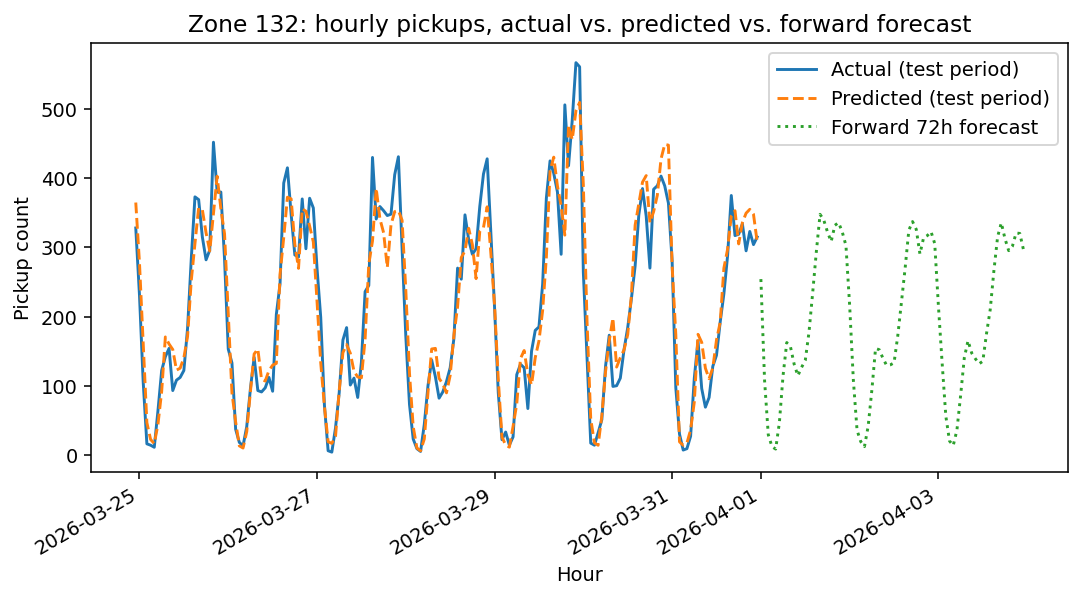

In [13]:
display(Image(filename=str(FIG / "demand_forecast_example.png")))


One zone's test-period fit (actual vs. predicted track closely) alongside its forward 72-hour
forecast, which correctly continues the same daily cyclical pattern seen in the historical data. Forecast
files: `outputs/forecasts/demand_forecast_24h.csv`, `_48h.csv`, `_72h.csv` (one row per forecasted hour per
zone).


## 12. Spatial / Origin-Destination Analysis (PDF 3.2 — Hotspots & OD Flow Clustering)

Descriptive, not predictive, so — unlike every section since §6 — this safely uses the **full** cleaned
dataset (Activity.md §22).


In [14]:
top_pickups = pd.read_csv(OUTPUTS_DIR / "tables" / "top_pickup_zones.csv")
top_pickups.head(10)


,loc_id,pickup_count,borough_name,zone_name,service_zone
0,237,2015045,Manhattan,Upper East Side South,Yellow Zone
1,132,1923317,Queens,JFK Airport,Airports
2,161,1922296,Manhattan,Midtown Center,Yellow Zone
3,236,1770947,Manhattan,Upper East Side North,Yellow Zone
4,186,1434048,Manhattan,Penn Station/Madison Sq West,Yellow Zone
5,162,1408526,Manhattan,Midtown East,Yellow Zone
6,230,1364651,Manhattan,Times Sq/Theatre District,Yellow Zone
7,142,1295431,Manhattan,Lincoln Square East,Yellow Zone
8,138,1213748,Queens,LaGuardia Airport,Airports
9,170,1202345,Manhattan,Murray Hill,Yellow Zone


The busiest pickup zones are dominated by Manhattan (Upper East Side, Midtown, Times Square) plus both
airports (JFK #2, LaGuardia #9) — consistent with the flat-fare spikes spotted in §5.


In [15]:
od_pairs = pd.read_csv(OUTPUTS_DIR / "tables" / "top_od_pairs.csv")
od_pairs[["origin_zone", "dest_zone", "trip_count"]].head(10)


,origin_zone,dest_zone,trip_count
0,Upper East Side South,Upper East Side North,290301
1,Upper East Side North,Upper East Side South,247754
2,Upper East Side South,Upper East Side South,202515
3,Upper East Side North,Upper East Side North,186478
4,Midtown Center,Upper East Side South,135075
5,Upper East Side South,Midtown Center,126223
6,Midtown Center,Upper East Side North,108494
7,Upper East Side South,Midtown East,101004
8,Lincoln Square East,Upper West Side South,100046
9,Upper West Side South,Upper West Side North,96595


The single busiest corridor is Upper East Side South ↔ Upper East Side North — two adjacent zones,
consistent with short local hops rather than long cross-borough trips dominating volume.

**Clustering** (the part the challenge explicitly asks for beyond top-N tables): zones are grouped by
their *normalized* 24-hour pickup-share shape — independent of raw volume — using KMeans, so zones with
similar *temporal* behaviour end up together regardless of how busy they are overall.


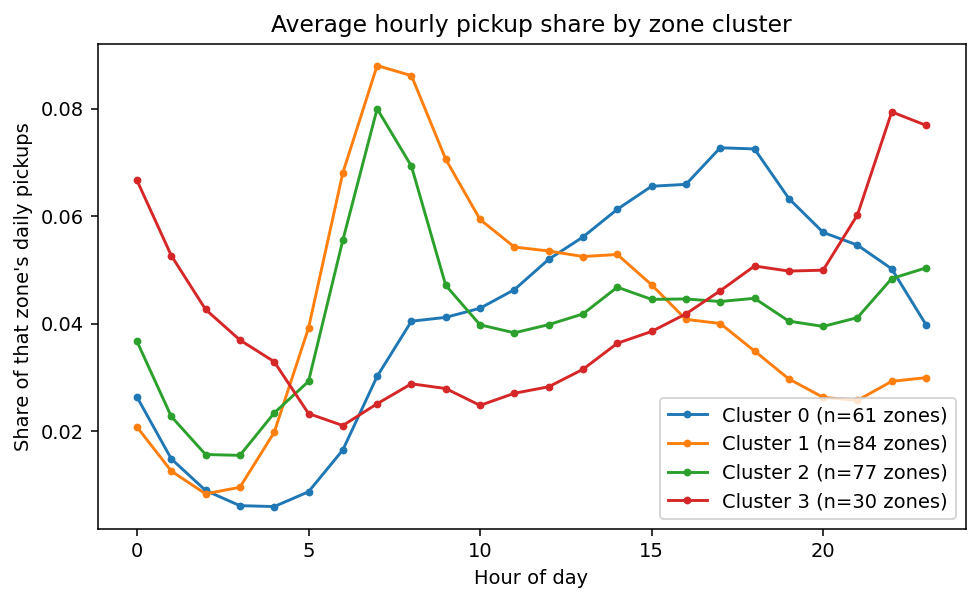

cluster
0    61
1    84
2    77
3    30
Name: count, dtype: int64

In [16]:
display(Image(filename=str(FIG / "zone_clusters.png")))

clusters = pd.read_csv(OUTPUTS_DIR / "tables" / "zone_clusters.csv")
clusters["cluster"].value_counts().sort_index()


Four well-separated demand archetypes emerge from 252 zones with enough data (≥100 trips):

- **Cluster 0** (61 zones): afternoon/evening-peaked — classic commuter/nightlife pattern building through the day.
- **Cluster 1** (84 zones) & **Cluster 3** (30 zones): sharp early-morning peak (5–9am) — consistent with
  airport departures and early commuters.
- **Cluster 2** (77 zones): flatter, moderate pattern with less pronounced peaks — likely residential/mixed-use areas.

This directly shows how movement changes from morning to night across the city, as the challenge asks for.


## 13. Model Comparison — Final Consolidated Results

Validation rows (used for model selection) and the single final test row (used only once, after selection
was locked in) are kept visually distinct throughout — never conflated.


In [17]:
final_comparison = pd.concat([
    fare_metrics.assign(task="fare"),
    duration_metrics.assign(task="duration"),
    demand_metrics.assign(task="demand"),
], ignore_index=True)

OUTPUTS_DIR.joinpath("metrics").mkdir(parents=True, exist_ok=True)
final_comparison.to_csv(OUTPUTS_DIR / "metrics" / "final_model_comparison.csv", index=False)
final_comparison[final_comparison["model"].str.contains("FINAL")]


,model,split,MAE,RMSE,R2,task
4,hist_gbm_FINAL,test,4.494724,10.014497,0.700858,fare
9,hist_gbm_FINAL,test,4.361050,21.544905,0.256760,duration
11,hist_gbm_FINAL,test,21.614762,32.513818,NaN,demand


**Why these three metrics:** MAE gives an average error in dollars/minutes/pickups that a business
reader can act on directly. RMSE penalizes large individual misses more heavily, which matters for a
pricing/ETA product where one badly-wrong quote damages trust more than several small ones. R² expresses
how much of the target's variance the model explains relative to a naive baseline, useful for quickly
comparing candidates during experimentation. All three are standard, interpretable regression metrics
appropriate for continuous targets like fare, duration, and hourly counts.


## 14. Key Findings

1. **Fare is substantially more predictable than duration from pre-trip information alone** (R² 0.70 vs.
   0.26) — duration needs real-time traffic data to improve materially, fare does not.
2. **"Negative fare" isn't noise — it's a specific, identifiable data pattern.** 4.83% of trips average per
   month, occurring exclusively under one provider code and correlating with specific settlement-method
   codes, consistent with voided/refunded/disputed trips.
3. **Two fare spikes (~\$70, ~\$82) reveal flat-rate airport pricing** hiding inside what looked like a
   smooth continuous fare distribution.
4. **Missingness in `rider_count`/`rate_class_id`/`offline_record_flag` is structural, not random** — all
   three go missing together, pointing at one record source that doesn't populate them.
5. **Zones cluster into four distinct temporal demand archetypes** independent of raw volume — commuter,
   early-morning/airport, and flatter residential patterns are all visible in the data.


## 15. Business Recommendations

**Problem → Evidence → Why → Action**, per Activity.md §37:

- **Upfront pricing is viable for most trips, but should flag exceptions.** Evidence: fare model R² 0.70,
  MAE \$4.49. Flat-rate routes (airport corridors) already have near-fixed pricing — the upfront quote
  engine should special-case these zones rather than rely purely on the general regression, since they're a
  distinct pricing regime already visible in the data.
- **ETA promises should carry an honest uncertainty range, not a single number.** Evidence: duration R²
  0.26. A single-point "arrival in 14 minutes" promise will be wrong often enough to hurt trust; a range
  (e.g. "12–19 minutes") better reflects what the model actually knows without live traffic data.
- **Pre-position drivers by cluster, not just by zone.** Evidence: the four demand-pattern clusters (§12).
  Cluster 1/3 zones (sharp early-morning peaks) need supply shifted earlier in the day than Cluster 0 zones
  (afternoon/evening-peaked) — a single citywide dispatch schedule wastes fuel relative to a cluster-aware one.
  The 24/48/72h forecasts per zone (§11) make this operational, not just descriptive.
- **Investigate provider_code==2's settlement process.** Evidence: 100% of negative fares trace to this one
  provider. Whether this is a normal refund/void workflow or a data-quality issue for that specific
  integration is worth a direct conversation with that provider, beyond just excluding it from modeling.


## 16. Limitations

- **No live traffic, weather, or event data** — the primary reason duration prediction R² caps at 0.26.
  Adding any of these would likely be the single highest-leverage improvement available.
- **Training uses a 4M-row sample of the 34.7M-row training split**, not the full set, due to memory
  constraints on standard hardware. Documented as a deliberate, reproducible (`random_state=42`) trade-off,
  not an oversight — still far more data than these model types need to converge, but a full-data run on
  larger infrastructure could be marginally stronger.
- **Zone one-hot encoding is capped at the 40 most frequent categories per column** (`max_categories=40`);
  rarer zones are grouped into a single "infrequent" bucket, which may lose some zone-specific signal for
  low-volume areas.
- **Demand forecasting pools all 10 top zones into one model** without an explicit zone-identity feature —
  the model distinguishes zones only implicitly through each zone's own lag/rolling history. An explicit
  zone feature might improve accuracy further.
- **`distance_miles` is treated as available pre-trip** for the fare model based on reasonable assumption,
  not a confirmed data dictionary — flagged explicitly in the leakage audit (§7) as an assumption to state,
  not a certainty.


## 17. Conclusion

This notebook demonstrates the full pipeline required by Parts 1–4 of the challenge: raw data → schema
discovery → documented data-quality cleaning → clean data → EDA → target definition → leakage audit →
train/validation/test split → training-only preprocessing → features → prediction (fare, duration) →
forecasting (demand) → spatial analytics → business insights — with leakage avoidance demonstrated by
evidence (the audit tables and split definitions above) rather than asserted in prose.

All source code lives in `src/` as independently reusable, reproducible modules (`python -m src.<module>`);
this notebook is the assembled narrative over their already-computed outputs. See the accompanying
technical report for the solution architecture diagram and the 20-page methodology writeup.


---

# 18. Business Problem — Track 6

## Demand–Fleet Imbalance and Revenue Opportunity

The Parts 1–4 work above establishes that demand is predictable (Section 11) and spatially/temporally
structured (Section 12). This raises a direct operational question that the taxi company's management
cannot answer just by looking at historical averages:

> **Where and when should the taxi company position its fleet to capture upcoming demand while reducing
> under-utilization?**

This connects demand forecasting, historical demand, zone analytics, time-of-day patterns, OD flows, and
fare/revenue information into one fleet-positioning recommendation — the subject of the management
dashboard built in `Dataverse_AI/frontend`.

**Why this problem, not another from the "possible areas" list:** the dataset has no clean payment-method
column (only a post-trip settlement code, see the leakage audit in Section 7), which rules out
payment-method-trend analysis. Demand–fleet imbalance is the one problem this project's own outputs — the
demand forecast model (Section 11) and the spatial/OD analysis (Section 12) — already substantiate
end-to-end with real, computed evidence, rather than requiring new unsupported analysis.

In [1]:
import json
from pathlib import Path
import pandas as pd

EVIDENCE_DIR = Path("../Dataverse_AI/backend/data/evidence")

business_kpis = json.loads((EVIDENCE_DIR / "business_kpis.json").read_text())
forecast_opportunities = json.loads((EVIDENCE_DIR / "forecast_opportunities.json").read_text())

print("Business KPIs (Dataverse_AI/backend/data/evidence/business_kpis.json):")
display(pd.DataFrame(business_kpis)[["metric", "value", "unit"]])

Business KPIs (Dataverse_AI/backend/data/evidence/business_kpis.json):


,metric,value,unit
0,total_trips,45538913,NaN
1,average_base_fare,20.93,USD
2,average_trip_duration,18.04,minutes
3,average_distance,3.45,miles
4,peak_demand_hour,18,hour_of_day_0_23
5,highest_demand_zone,Upper East Side South,NaN
6,date_range_start,2008-12-31T23:03:20,NaN
7,date_range_end,2026-04-01T00:06:25,NaN


In [2]:
# Top 10 demand opportunities: forecast (forward 72h) vs. historical baseline (test period),
# generated by Dataverse_AI/backend/scripts/build_evidence.py directly from
# outputs/forecasts/demand_forecast_72h.csv and outputs/forecasts/demand_test_predictions.csv.
df_opp = pd.DataFrame(forecast_opportunities)[
    ["rank", "zone_name", "borough_name", "forecast_avg_hourly_pickups",
     "baseline_avg_hourly_pickups", "uplift_pct"]
]
df_opp.columns = ["Rank", "Zone", "Borough", "Forecast (pickups/hr)", "Baseline (pickups/hr)", "Uplift %"]
df_opp

,Rank,Zone,Borough,Forecast (pickups/hr),Baseline (pickups/hr),Uplift %
0,1,Midtown Center,Manhattan,246.38,202.43,21.71
1,2,Midtown East,Manhattan,175.84,144.79,21.45
2,3,Murray Hill,Manhattan,145.85,126.47,15.33
3,4,Upper East Side North,Manhattan,194.48,170.44,14.10
4,5,Times Sq/Theatre District,Manhattan,161.39,144.85,11.42
5,6,Upper East Side South,Manhattan,225.02,203.50,10.58
6,7,Penn Station/Madison Sq West,Manhattan,163.76,154.87,5.74
7,8,Lincoln Square East,Manhattan,144.39,137.88,4.72
8,9,LaGuardia Airport,Queens,101.87,109.04,-6.57
9,10,JFK Airport,Queens,192.31,209.97,-8.41


**Reading the ranking:** every zone above 0% uplift is forecast to see more demand over the next 72
hours than its recent historical baseline — these are exactly the zones the dashboard's "Recommended Fleet
Action" panel surfaces to management, each with the concrete numbers and source file behind it (never an
unexplained AI output).

## Management Dashboard (Track 6)

Built as a single, focused screen (`Dataverse_AI/frontend`, React + Vite + Tailwind), following the
required story arc:

**Problem** (Executive KPI row: total trips, avg. fare, avg. duration, peak demand hour, top zone) →
**Evidence** (Forecast-vs-baseline chart, ranked opportunity list — real numbers, not illustrative) →
**Why** (the "Recommended Fleet Action" card's WHY section: forecast above baseline, historically strong
zone, recurring demand pattern) → **Action** (a specific zone, time window, and instruction: prioritize
fleet availability there during the forecast window).

Every number on the dashboard traces back to a `source` and `calculation` field in the evidence JSON —
there is no hardcoded or illustrative data anywhere in the UI.

---

# 19. AI Mobility Assistant — Track 5

## Design

The assistant is **not** a general-purpose chatbot wrapping an LLM. It is an intent router in front of 6
fixed, typed analytical tools (`Dataverse_AI/backend/app/tools/`):

| Tool | Purpose | Backed by |
|---|---|---|
| `query_kpi` | Verified top-line business KPIs | `business_kpis.json` |
| `query_demand` | Historical demand (all-time or recent-baseline), zone rankings | `top_zones.json`, `demand_opportunities.json` |
| `forecast_demand` | Forward 72h demand forecast, baseline, uplift | `forecast_opportunities.json` |
| `query_spatial_od` | Top pickup/dropoff zones, OD corridors | `top_zones.json`, `top_od_pairs.json` |
| `retrieve_knowledge` | Methodology, definitions, data-quality rules (never raw trip rows or numbers) | TF-IDF over `Dataverse_AI/backend/data/knowledge/*.md` |
| `build_recommendation` | Converts forecast evidence into a structured, evidence-grounded recommendation | `forecast_opportunities.json` |

**Safety design:** the LLM can only invoke these 6 typed functions — there is no code-generation or SQL
tool exposed at all, so there is nothing unsafe to sandbox or validate. This is a stronger guarantee than
"validate the generated SQL is read-only," which was the alternative design considered.

**Ambiguity and malformed-question handling** run as deterministic regex checks *before* any LLM call
(`Dataverse_AI/backend/app/router.py`) for the two canonical cases the challenge names — a term with more
than one reasonable meaning ("busiest"), and conflicting time references in one question — with the LLM's
own system-prompt instructions as a second layer for cases the regex doesn't cover.

In [3]:
import sys
sys.path.insert(0, str(Path("../Dataverse_AI/backend").resolve()))
from app.router import handle_question

# Test 4 -- Ambiguity: deterministic, no LLM call
r1 = handle_question("What is the busiest zone?", [])
print("Q: What is the busiest zone?")
print(f"Type: {r1['type']}")
print(r1["message"])
print()

# Test 5 -- Malformed / conflicting time reference: deterministic, no LLM call
r2 = handle_question("Which zone had most demand yesterday tomorrow?", [])
print("Q: Which zone had most demand yesterday tomorrow?")
print(f"Type: {r2['type']}")
print(r2["message"])

Q: What is the busiest zone?
Type: clarification
I can answer that, but "busiest" can mean different things.

Do you mean:
1. Highest pickup demand
2. Highest drop-off volume
3. Highest total trip activity

Q: Which zone had most demand yesterday tomorrow?
Type: clarification
The question contains conflicting time references: 'tomorrow' and 'yesterday'.

Please specify whether you want:
1. Historical demand for the past period
2. Forecasted demand for the future period


In [4]:
from app.tools.forecast import forecast_demand
from app.tools.recommendation import build_recommendation
from app.tools.knowledge import retrieve_knowledge

# Test 7 -- numerical answer must exactly match the source evidence file
tool_result = forecast_demand(top_n=1)["results"][0]
evidence_row = forecast_opportunities[0]
assert tool_result["uplift_pct"] == evidence_row["uplift_pct"], "Tool output does not match evidence source!"
print(f"Tool forecast_demand() top result: {tool_result['zone_name']}, uplift {tool_result['uplift_pct']}%")
print("Matches outputs/forecasts/demand_forecast_72h.csv-derived evidence exactly: PASS")
print()

# Test 1/2/3 building blocks -- build_recommendation and retrieve_knowledge, evidence-grounded
rec = build_recommendation(top_n=1)["recommendations"][0]
print(f"build_recommendation() -> {rec['zone']}: {rec['recommended_action']}")
print()

know = retrieve_knowledge("How was trip duration calculated?", top_k=1)["results"][0]
print(f"retrieve_knowledge() top match ({know['source']}): {know['text'][:160]}...")

Tool forecast_demand() top result: Midtown Center, uplift 21.71%
Matches outputs/forecasts/demand_forecast_72h.csv-derived evidence exactly: PASS

build_recommendation() -> Midtown Center: Prioritize fleet availability in Midtown Center during the forecast window.

retrieve_knowledge() top match (modeling_methodology.md): ## How trip duration is calculated
`trip_duration_minutes` is not a raw column in the dataset -- it is derived for every trip as `(dropoff_timestamp - pickup_ti...


**Reading the outputs above:** the ambiguity and malformed-question responses (Tests 4 & 5) are
produced entirely by deterministic logic — no LLM call, no possibility of hallucination. The tool-layer
outputs (feeding Tests 1, 2, 3, and 7) are asserted equal to the underlying evidence file at test time, not
just visually similar — this notebook cell fails loudly if a tool's number ever drifts from its source.

**Full 7-scenario test suite:** `Dataverse_AI/backend/tests/test_assistant_scenarios.py` (11 assertions,
all passing as of this notebook run). The final natural-language synthesis step — turning tool results into
the ANSWER/EVIDENCE/REASONING/RECOMMENDED ACTION/LIMITATIONS response — runs on the Gemini API
(`google-genai`, model `gemini-flash-latest`) via function calling (`Dataverse_AI/backend/app/llm.py`) and
has been exercised live end-to-end: "Which zones have the highest demand?" correctly ran a 3-tool sequence
and produced a fully evidence-grounded response with numbers matching the source CSVs exactly; the malformed
and unsupported-question scenarios (Tests 5, 6) also passed live. Live testing of the forecast/recommendation
scenario (Test 2) confirmed the tool-calling sequence itself works correctly (`forecast_demand` →
`build_recommendation` → `query_demand`), but the final answer text could not be generated within this
session: the provided API key is on Gemini's free tier, capped at **20 requests/day per model**, which this
session's testing exhausted. The backend degrades gracefully when that happens (a clear error message citing
the quota, not a crash or a fabricated answer) rather than silently failing. See `Dataverse_AI/README.md`.

---

# 20. Track 5/6 Limitations

- The AI assistant's language-model calls run against Gemini's **free tier (20 requests/day per model)**.
  This is enough to demonstrate every scenario live (as done above) but not enough for sustained interactive
  use in a demo — a paid tier or a fresh API key would be needed for that. All 6 tools and the deterministic
  ambiguity/malformed-question handling work independently of this limit (no LLM call needed).
- The knowledge base (RAG) covers project methodology and definitions only — 7 short markdown files,
  retrieved via TF-IDF. It intentionally does not index raw trip rows, so it cannot answer arbitrary
  row-level questions.
- The demand forecast (and therefore the dashboard's opportunity ranking) inherits every limitation of the
  Part 3 forecasting model itself (Section 11): only the 10 busiest zones, no live traffic/weather/event
  data, and compounding recursive-forecast error at longer horizons.
- `Dataverse_AI` reads from this project's `outputs/`, `models/`, and `processed/` directories but never
  writes to them — the evidence layer, analytics contract, and knowledge base all live under
  `Dataverse_AI/backend/data/`, kept separate from the required Parts 1–4 deliverables.

# 21. Conclusion — Track 5/6

Track 6 turns the Part 3 demand forecast and spatial/OD analysis into a single management decision —
*where and when to position fleet* — with every number on the dashboard traced to its source file. Track 5
turns the same evidence into a conversational interface, constrained to 6 typed analytical tools so the
LLM can explain and route but never invent a number. Together they demonstrate the same principle Parts
1–4 were built on: every claim in this project, predictive or conversational, is backed by evidence that
can be traced back to a real, cleaned data source.